   ID  Age  Experience  Income  ZIP Code  Family  CCAvg  Education  Mortgage  \
0   1   25           1      49     91107       4    1.6          1         0   
1   2   45          19      34     90089       3    1.5          1         0   
2   3   39          15      11     94720       1    1.0          1         0   
3   4   35           9     100     94112       1    2.7          2         0   
4   5   35           8      45     91330       4    1.0          2         0   

   Personal Loan  Securities Account  CD Account  Online  CreditCard  
0              0                   1           0       0           0  
1              0                   1           0       0           0  
2              0                   0           0       0           0  
3              0                   0           0       0           0  
4              0                   0           0       0           1  
(5000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data col

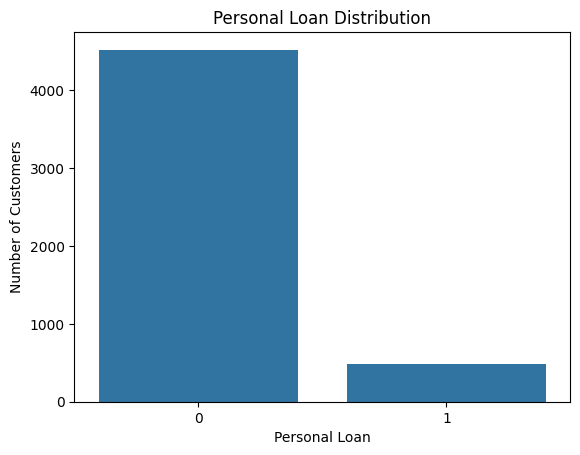

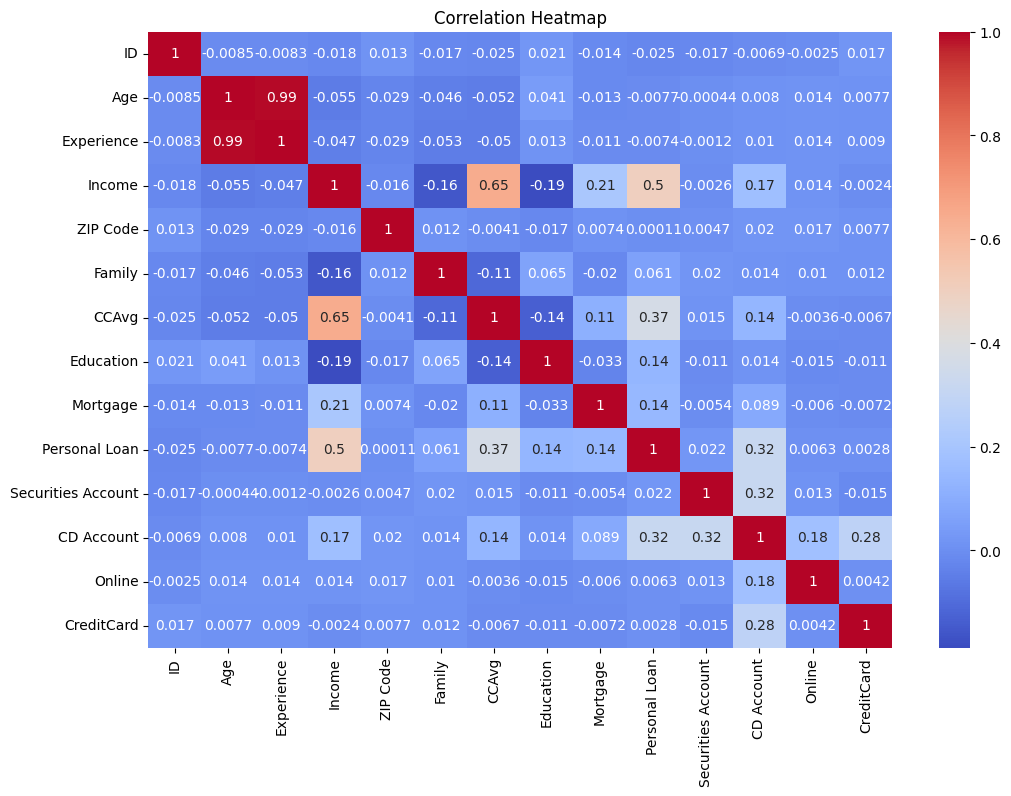

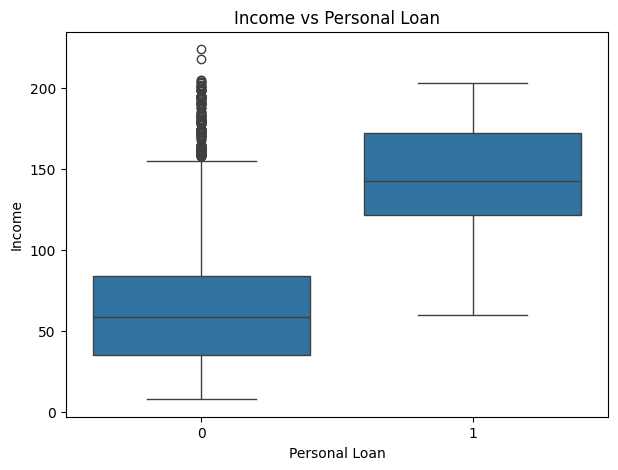

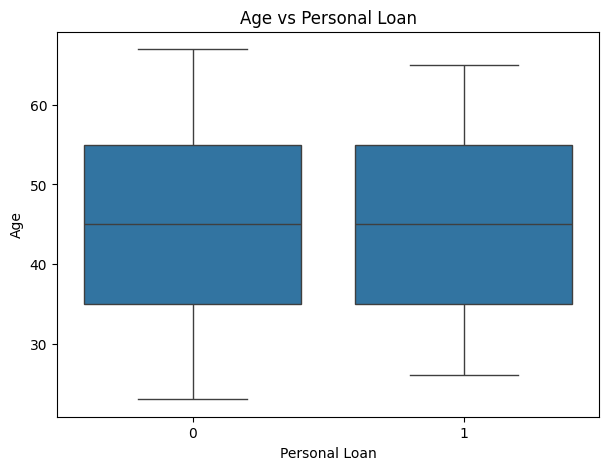

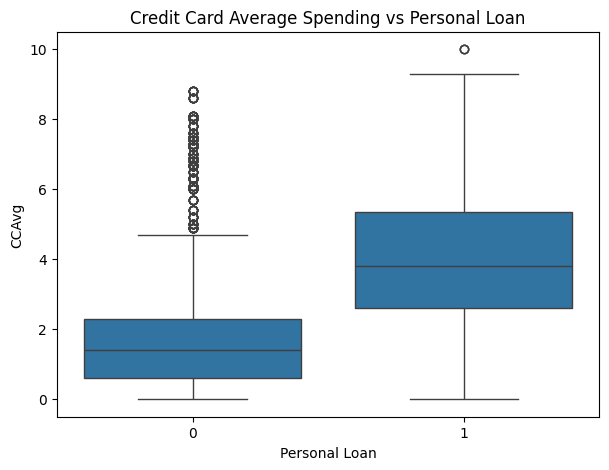

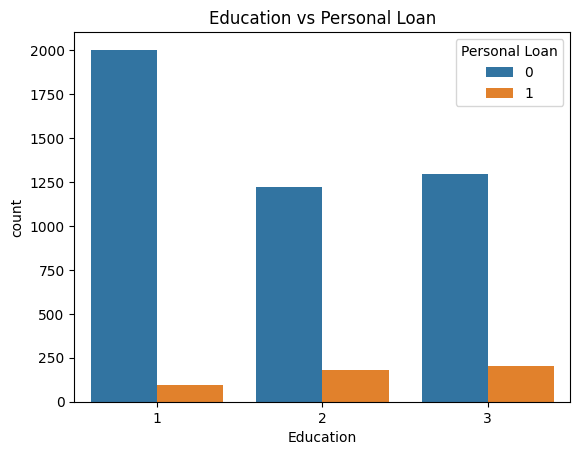

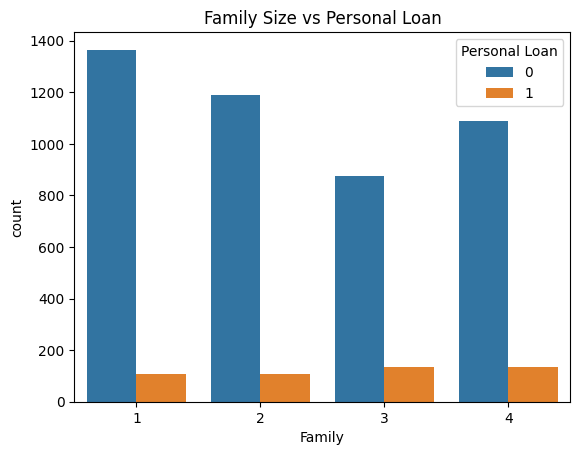


Model Results
Accuracy : 0.978
Precision: 0.9743589743589743
Recall   : 0.7916666666666666
F1 Score : 0.8735632183908046

Confusion Matrix:
[[902   2]
 [ 20  76]]


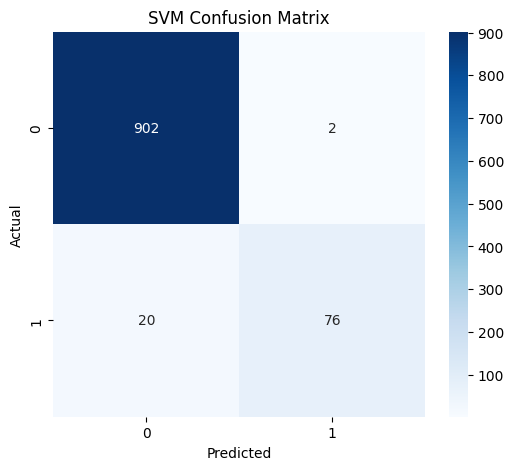


Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       904
           1       0.97      0.79      0.87        96

    accuracy                           0.98      1000
   macro avg       0.98      0.89      0.93      1000
weighted avg       0.98      0.98      0.98      1000



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


df = pd.read_csv("/content/UniversalBank.csv")


print(df.head())
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(df.duplicated().sum())


print(df["Personal Loan"].value_counts())
print(df["Personal Loan"].value_counts(normalize=True) * 100)


sns.countplot(x="Personal Loan", data=df)
plt.title("Personal Loan Distribution")
plt.xlabel("Personal Loan")
plt.ylabel("Number of Customers")
plt.show()


plt.figure(figsize=(12, 8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()


plt.figure(figsize=(7, 5))
sns.boxplot(
    x="Personal Loan",
    y="Income",
    data=df
)
plt.title("Income vs Personal Loan")
plt.show()


plt.figure(figsize=(7, 5))
sns.boxplot(
    x="Personal Loan",
    y="Age",
    data=df
)
plt.title("Age vs Personal Loan")
plt.show()


plt.figure(figsize=(7, 5))
sns.boxplot(
    x="Personal Loan",
    y="CCAvg",
    data=df
)
plt.title("Credit Card Average Spending vs Personal Loan")
plt.show()


sns.countplot(
    x="Education",
    hue="Personal Loan",
    data=df
)
plt.title("Education vs Personal Loan")
plt.show()


sns.countplot(
    x="Family",
    hue="Personal Loan",
    data=df
)
plt.title("Family Size vs Personal Loan")
plt.show()


df = df.drop(columns=["ID", "ZIP Code"])

X = df.drop(columns=["Personal Loan"])
y = df["Personal Loan"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


model = SVC(
    kernel="rbf",
    C=1,
    gamma="scale"
)


model.fit(X_train_scaled, y_train)


y_pred = model.predict(X_test_scaled)


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


print("\nModel Results")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)


cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


print("\nClassification Report:")
print(classification_report(y_test, y_pred))